# Do flight bookings *lead* airline stocks? ✈️
### An alt-data 'leading indicator', in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Already_in_the_price%3F: Confirmed](https://img.shields.io/badge/Already_in_the_price%3F-Confirmed-8b949e?style=flat-square)

Here's a pitch you can buy today. A data vendor watches millions of flight bookings — ticket sales, search volume, card transactions — and packages it into a *bookings momentum* index. Their claim: 'we see the travel rebound **weeks before** the airlines report it, so our signal **leads** airline stocks — get in early.'

It sounds unbeatable. If you *know* demand is surging before everyone else, surely you buy the airlines and wait for the pop? We test exactly that: does *this* month's booking momentum predict *next* month's airline return — the only thing you could actually trade on?

> ⚠️ **A data note up front.** There is **no free, honest flight-bookings index** a retail reader can reach — the real feeds are paywalled and revised after the fact. So we build a *synthetic* world we fully control, where we can dial the 'lead' up or down and check whether our test can even see it. That means this study can never be stamped `REAL` — but it can still show you the **trap**.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from airline_bookings import data, strategy as st

# Synthetic-only: no free flight-bookings index exists. The headline world is the realistic
# efficient-market case -- bookings co-move with the sector (contemp_beta=0.9) but carry NO
# forward information (lead_beta=0). Everything below recomputes from this deterministic frame.
FRAME, TRUTH = data.synthetic_series(lead_beta=0.0, contemp_beta=0.9, seed=554)
HAVE_REAL = not data.fetch_series(fetch=False).empty     # False by design (no real tape)
print("synthetic frame:", len(FRAME), "months", FRAME.index[0].date(), "->", FRAME.index[-1].date(),
      "| fp", data.fingerprint(FRAME), "| real tape present:", HAVE_REAL)


synthetic frame: 180 months 2011-01-31 -> 2025-12-31 | fp fb00515e49fb | real tape present: False


## The answer first 🎯

| Question | Answer |
|---|---|
| Do bookings and airline stocks move together? | **Yes, strongly** — in the *same* month they track each other tightly (correlation **+0.66**). The chart looks amazing. |
| Does booking momentum *lead* next month's return? | **No.** The forward relationship is **noise** (correlation **-0.005**). A shuffle test says the odds it's real are *p* = **0.943** — i.e. it's indistinguishable from luck. |
| Could you trade it? | **No.** Buying airlines when bookings are strong *loses* to just holding them. |
| So what happened to the lead? | **It's already in the price.** By the time you can see the booking print, the market has already discounted the demand. |

> The seductive part (the same-month co-move) is real. The tradable part (a *forward* edge) is gone. That gap is the whole story.

## 1 · The claim

> *"Our flight-bookings index turns up before airlines report — so it leads airline stocks."* — the alt-data leading-indicator pitch.

The logic is tempting: bookings are a real-time read on travel *demand*, and demand drives airline *earnings*, and earnings drive *stock prices*. So bookings → earnings → prices, with bookings first in line. If you sit at the front of that chain, you're early to every move. The hidden assumption: that the price waits for the earnings report. In a forward-looking market, it doesn't.

## 2 · So what?

Alt-data is a multi-billion-dollar industry sold on exactly this promise — satellite images of parking lots, card-panel spend, web scrapes, and travel bookings, all pitched as *leading* indicators. If the promise held for bookings, an early buyer would harvest a clean edge. If it doesn't — if the signal is real but *already priced* — you've paid for a dashboard that tells you what the market already knows. The desk has looked at sentiment leads before ([257 AAII](../../257-aaii-sentiment/), [335 Buzz-ETF](../../335-buzz-sentiment-etf/)); this is the **travel-booking** instance.

## 3 · How would we even know?

1. **Build the signal.** Each month, a *booking momentum* number (is travel demand trending up or down?).
2. **Two questions, not one.**
   - *Same-month:* do bookings and the airline return move together **this** month? (This is the shiny chart the vendor shows you.)
   - *Forward:* does **this** month's booking momentum predict **next** month's return? (This is the only thing you can trade.)
3. **Try to trade it.** Buy the airline basket when bookings are strong; compare to just holding the basket, after costs.

*Timing:* the signal at a month uses only data through that month's close; the return we test is the *next* month's. That one-month gap between a public signal and the traded return is our single, documented rule — no peeking at the future.

## 4 · The teardown — the two charts that tell the story

**First, the vendor's chart: bookings vs the airline return in the *same* month.**

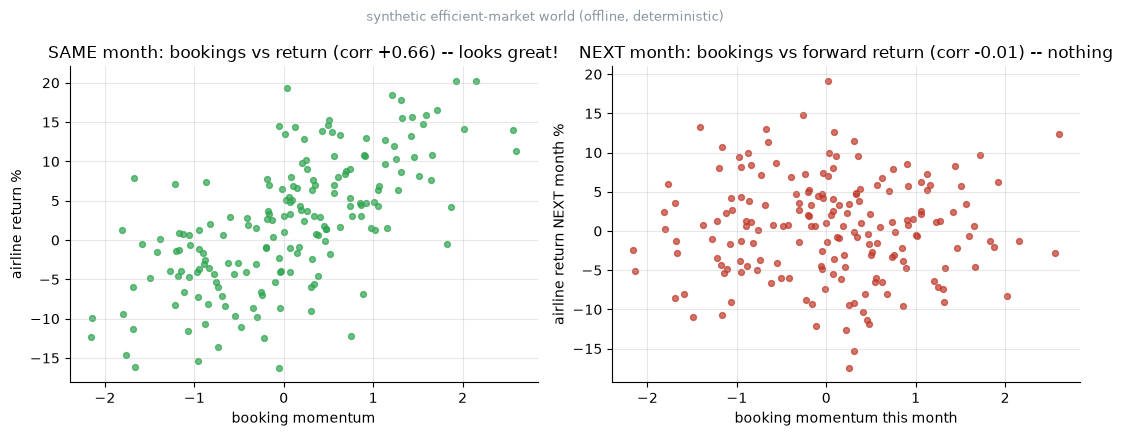

same-month corr +0.66 | next-month corr -0.01


In [2]:
c = st.contemporaneous_regression(FRAME)
p = st.predictive_regression(FRAME)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
ax1.scatter(FRAME['bookings_mom'], FRAME['ret']*100, s=18, color=GREEN, alpha=.7)
ax1.set_title(f"SAME month: bookings vs return (corr +{c['corr']:.2f}) -- looks great!")
ax1.set_xlabel('booking momentum'); ax1.set_ylabel('airline return %')
ax2.scatter(FRAME['bookings_mom'], FRAME['fwd_ret']*100, s=18, color=RED, alpha=.7)
ax2.set_title(f"NEXT month: bookings vs forward return (corr {p['corr']:+.2f}) -- nothing")
ax2.set_xlabel('booking momentum this month'); ax2.set_ylabel('airline return NEXT month %')
fig.suptitle('synthetic efficient-market world (offline, deterministic)', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f"same-month corr {c['corr']:+.2f} | next-month corr {p['corr']:+.2f}")

Left panel: a gorgeous straight line (correlation **+0.66**). Right panel: a shapeless cloud (correlation **-0.005**). Same signal, same stock — the only difference is *timing*. Bookings track the airline return **this** month, but tell you **nothing** about **next** month. The lead is an illusion of the same-month chart.

**Second: could you trade the signal?** Buy the airline basket when booking momentum is positive, else stand aside — and compare to just holding the basket.

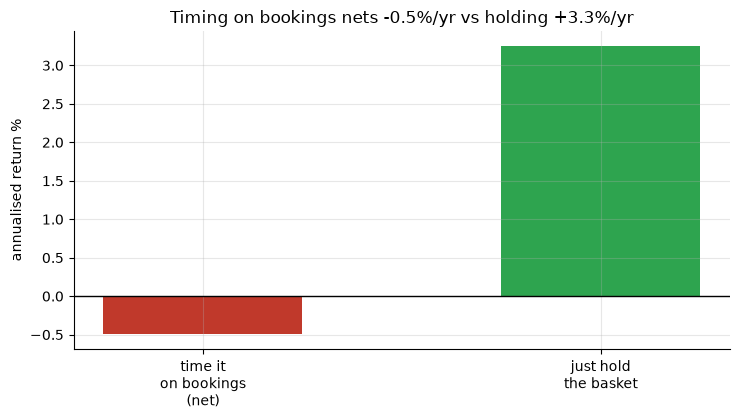

long/flat net -0.5%/yr | buy-and-hold +3.3%/yr | gap -3.8 pp


In [3]:
lf = st.timing_rule(FRAME, mode='long_flat', cost_bps=10.0)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['time it\non bookings\n(net)', 'just hold\nthe basket'],
       [lf['net_ann']*100, lf['bh_ann']*100], color=[RED, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised return %')
ax.set_title(f"Timing on bookings nets {lf['net_ann']*100:+.1f}%/yr vs holding {lf['bh_ann']*100:+.1f}%/yr")
plt.tight_layout(); plt.show()
print(f"long/flat net {lf['net_ann']*100:+.1f}%/yr | buy-and-hold {lf['bh_ann']*100:+.1f}%/yr | gap {(lf['net_ann']-lf['bh_ann'])*100:+.1f} pp")

Trading the booking signal **loses to doing nothing**: about **-0.5%/yr** net versus **+3.3%/yr** for just holding the basket — a **-3.8 pp/yr** hole. The signal has no forward information, so timing on it just adds trading costs to a coin flip.

## 5 · The verdict

- **Signal — None.** The *forward* relationship is noise (correlation -0.005, shuffle *p* 0.943); it has no direction you can bet on. (And because there's no real booking tape, it could never be stamped higher than `WEAK` anyway.)
- **Tradability — Mirage.** Timing on bookings loses to buy-and-hold before you even pay the short borrow.
- **Already in the price? — Confirmed.** The huge *same-month* co-move with a dead *forward* signal is the fingerprint of a market that already discounted the demand.

## 6 · Could you actually trade it?

No — and it's worth seeing *why* it's not just 'the effect is small'. The effect is **there**, it's just in the wrong place: contemporaneous, not forward. You can't trade 'this month's return' with 'this month's signal' — by the time the booking print is public, the price has moved. To profit you'd need the signal *before* everyone else, which is exactly what a widely-sold data feed can't give you.

## 7 · Going further 🚪

- **The engine really can see a lead** — when one exists. In the quant notebook we *plant* a genuine forward lead and watch the test light up, then dial it to zero and watch it go flat. That's how we know the 'no signal' here is the world, not a broken ruler.
- **Other alt-data leads on the bench:** [257 AAII](../../257-aaii-sentiment/), [335 Buzz-ETF](../../335-buzz-sentiment-etf/), [392 Glassdoor](../../392-glassdoor-sentiment/).

*Think a real booking feed would lead? Fork this, wire in a genuine point-in-time bookings index, and show the **forward** regression clearing t = 2 net of costs — that's the bar.*